# Imports

In [68]:
import os
import keras
from PIL import Image
from keras import layers
import matplotlib.pyplot as plt 
import tensorflow as tf

# Importering av data

In [60]:
if not os.path.exists("data/fashion_mnist_images/train") or not os.path.exists("data/fashion_mnist_images/test"):
    # raderar fel plaserad data eller gammal data
    
    if os.path.exists("data/fashion_mnist_images") and not os.path.exists("data/fashion_mnist_images/train") and not os.path.exists("data/fashion_mnist_images/test"): 
        print("starting to overwrite old data")
        for folder_name in os.listdir("data/fashion_mnist_images"):
            folder_path = os.path.join("data/fashion_mnist_images", folder_name)

            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path ,file_name)
                print(f"is file: {os.path.isfile(file_path)}, {file_path}")
                
                os.remove(file_path)  # Remove the file
                #print(f"removed file {file_path}")
        
        os.rmdir(folder_path)
        print(f"--removed folder {folder_path}")
                
    #  Ladda dataset
        (x_train, y_train),(x_test, y_test) = keras.datasets.fashion_mnist.load_data()

    # Klassnamn (viktigt för mappar)
        class_names = [
            "T-shirt_top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle_boot"
        ]

        # Root folder
        base_path = "data/fashion_mnist_images"

        # Skapa mappar per klass för tränings data
        if not os.path.exists(f"{base_path}/train"):

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"train", class_name), exist_ok=True)

            # Spara träningsbilder
            for i, (img, label) in enumerate(zip(x_train, y_train)):

                class_name = class_names[label]
                
                path = os.path.join(base_path,"train", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else:
             print("Test data already importet")

        if not os.path.exists(f"{base_path}/test"):
            # Skapa mappar per klass på test data

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"test", class_name), exist_ok=True)

            # Spara testbilder
            for i, (img, label) in enumerate(zip(x_test, y_test)):

                class_name = class_names[label]

                path = os.path.join(base_path,"test", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else: 
             print("Train data already importet")

        print("Done with importing data")
else:
     print("Data already been imported")

Data already been imported


# Standard model

## Inläsning av data

In [63]:
train_dir = "data/fashion_mnist_images/train"
test_dir = "data/fashion_mnist_images/test"


IMG_SIZE = (48, 48)
BATCH_SIZE = 128

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_data.class_names
normalization_layer = layers.Rescaling(1./255)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Första modelen

In [69]:
model_1 = keras.Sequential([
    layers.Input(shape=(48,48,1)),
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,434 (3.20 MB)

 Trainable params: 839,434 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

## Träning

In [70]:
history_1 = model_1.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.8381 - loss: 0.4553 - val_accuracy: 0.8730 - val_loss: 0.3533
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.8904 - loss: 0.2991 - val_accuracy: 0.8906 - val_loss: 0.3004
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9081 - loss: 0.2521 - val_accuracy: 0.8963 - val_loss: 0.2793
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9165 - loss: 0.2253 - val_accuracy: 0.9027 - val_loss: 0.2643
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9282 - loss: 0.1958 - val_accuracy: 0.9064 - val_loss: 0.2505
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9356 - loss: 0.1749 - val_accuracy: 0.9088 - val_loss: 0.2485
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9440 - loss: 0.1512 - val_accuracy: 0.9135 - val_loss: 0.2430
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9511 - loss: 0.1330 - 

# Jämförelse Model

## Inläsning av data

In [71]:
train_data_augmentation = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data_augmentation = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Data föränding

In [91]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

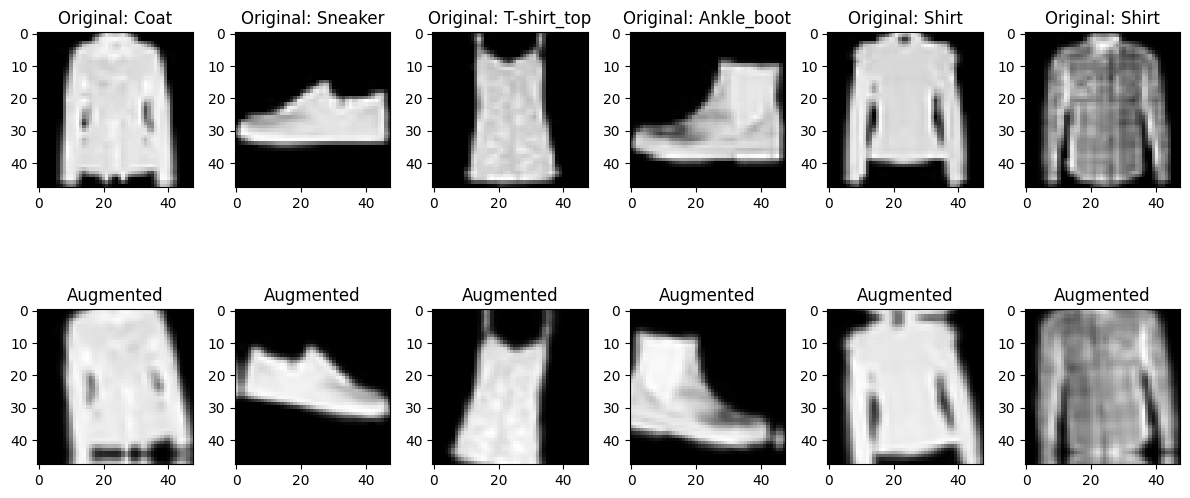

In [92]:

# Visualize 6 original clothing items with the augmented versions

plt.figure(figsize=(12, 6))

for images, labels in train_data_augmentation.take(1): 
    for i in range(6):
        sample_image = images[i]
        sample_label = labels[i]


        # Original image top row
        plt.subplot(2, 6, i + 1)
        plt.imshow(sample_image.numpy().squeeze(), cmap='gray')
        plt.title(f"Original: {class_names[sample_label]}")

        # Augmented images bottom row
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0))
        plt.subplot(2, 6, i + 7)
        plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
        plt.title(f"Augmented")

    plt.tight_layout()
    plt.show()


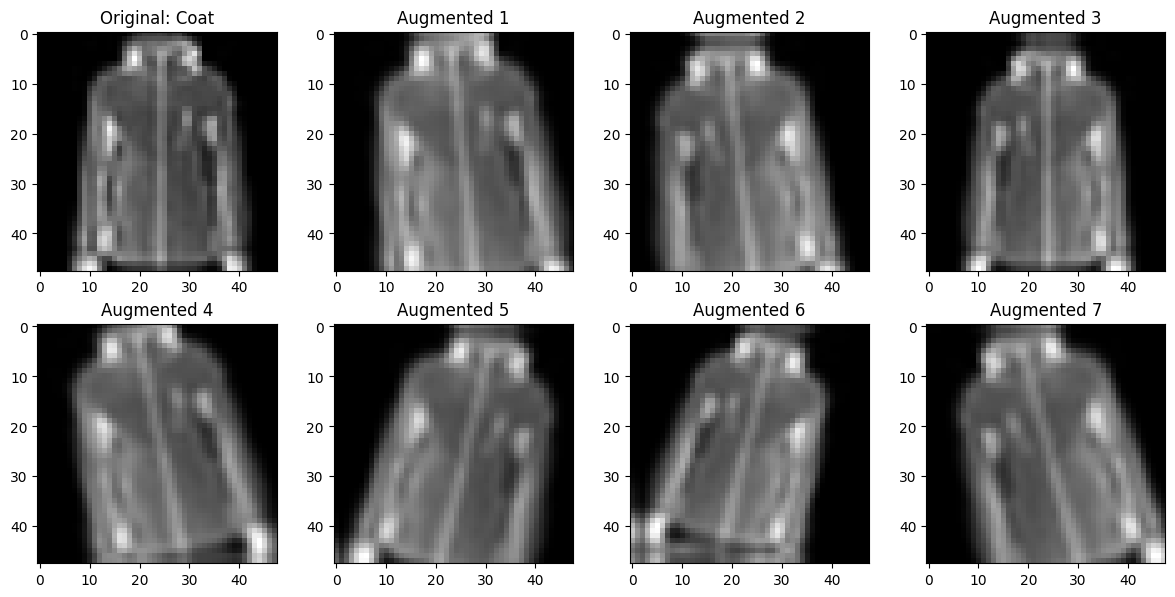

In [95]:
# Augmentation of the same picture

for images, labels in train_data_augmentation.take(1):
    sample_image = images[0]
    sample_label = labels[0]

    plt.figure(figsize=(12, 6))

# Original image
    plt.subplot(2, 4, 1)
    plt.imshow(sample_image.numpy().squeeze(), cmap='gray')
    plt.title(f"Original: {class_names[sample_label]}")

# Augmented images
    for i in range(7):
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0))
        plt.subplot(2, 4, i + 2)
        plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
        plt.title(f"Augmented {i+1}")

    plt.tight_layout()
    plt.show()

## Andra model

In [96]:
model_2 = keras.Sequential([
    layers.Input(shape=(48,48,1)),
    data_augmentation,
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    
    layers.Dense(len(class_names), activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,434 (3.20 MB)

 Trainable params: 839,434 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

## Träning

In [97]:
history_2 = model_2.fit(
    train_data_augmentation,
    validation_data=test_data_augmentation,
    epochs=15
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - accuracy: 0.7464 - loss: 0.6790 - val_accuracy: 0.8315 - val_loss: 0.4604
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8151 - loss: 0.4975 - val_accuracy: 0.8491 - val_loss: 0.4114
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8332 - loss: 0.4420 - val_accuracy: 0.8549 - val_loss: 0.3903
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8459 - loss: 0.4119 - val_accuracy: 0.8683 - val_loss: 0.3653
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8539 - loss: 0.3894 - val_accuracy: 0.8767 - val_loss: 0.3436
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8629 - loss: 0.3694 - val_accuracy: 0.8708 - val_loss: 0.3502
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8699 - loss: 0.3513 - val_accuracy: 0.8869 - val_loss: 0.3193
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8734 - loss: 0.3390 -

# Jämförelse

model 1


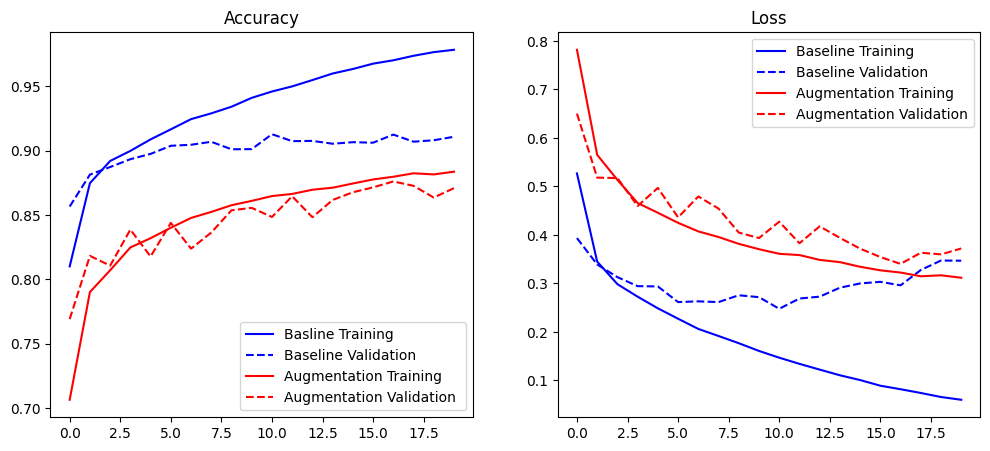

In [ ]:

print("model 1")
acc_1 = history_1.history['accuracy']
val_acc_1 = history_1.history['val_accuracy']

loss_1 = history_1.history['loss']
val_loss_1 = history_1.history['val_loss']

acc_2 = history_2.history['accuracy']
val_acc_2 = history_2.history['val_accuracy']

loss_2 = history_2.history['loss']
val_loss_2 = history_2.history['val_loss']


epochs_range_1 = range(len(acc_1))
epochs_range_2 = range(len(acc_2))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range_1, acc_1,'b', label='Basline Training') #b = Blue
plt.plot(epochs_range_1, val_acc_1, 'b--', label='Baseline Validation') #b-- = Blue med sträck
plt.plot(epochs_range_2, acc_2, 'r',label='Augmentation Training ')#r = Red 
plt.plot(epochs_range_2, val_acc_2,'r--', label='Augmentation Validation ') #r-- = Red med sträck
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range_1, loss_1, 'b',label='Baseline Training')
plt.plot(epochs_range_1, val_loss_1,'b--' ,label='Baseline Validation')
plt.plot(epochs_range_2, loss_2, 'r',label='Augmentation Training')
plt.plot(epochs_range_2, val_loss_2, 'r--',label='Augmentation Validation')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()